<a href="https://colab.research.google.com/github/MayShinPansy/lung-cancer-prediction/blob/main/MayShinThant_ml_mini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install keras_tuner --quiet
!pip install scikeras

In [ ]:
import kagglehub
import pandas as pd
import os

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import keras_tuner as kt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    r2_score,
    mean_squared_error,
    confusion_matrix
)



# Download the dataset
path = kagglehub.dataset_download("shantanugarg274/lung-cancer-prediction-dataset")

print("Path to dataset files:", path)
print("Files:", os.listdir(path))

# Load first CSV file
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
df = pd.read_csv(os.path.join(path, csv_files[0]))

# See shape
print("Shape:", df.shape)
print("Preview:")
print(df.head())

Path to dataset files: /kaggle/input/lung-cancer-prediction-dataset
Files: ['Lung Cancer Dataset.csv']
Shape: (5000, 18)
Preview:
   AGE  GENDER  SMOKING  FINGER_DISCOLORATION  MENTAL_STRESS  \
0   68       1        1                     1              1   
1   81       1        1                     0              0   
2   58       1        1                     0              0   
3   44       0        1                     0              1   
4   72       0        1                     1              1   

   EXPOSURE_TO_POLLUTION  LONG_TERM_ILLNESS  ENERGY_LEVEL  IMMUNE_WEAKNESS  \
0                      1                  0     57.831178                0   
1                      1                  1     47.694835                1   
2                      0                  0     59.577435                0   
3                      1                  0     59.785767                0   
4                      1                  1     59.733941                0   

   BREATHING_ISS

## Import datasets

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   AGE                     5000 non-null   int64  
 1   GENDER                  5000 non-null   int64  
 2   SMOKING                 5000 non-null   int64  
 3   FINGER_DISCOLORATION    5000 non-null   int64  
 4   MENTAL_STRESS           5000 non-null   int64  
 5   EXPOSURE_TO_POLLUTION   5000 non-null   int64  
 6   LONG_TERM_ILLNESS       5000 non-null   int64  
 7   ENERGY_LEVEL            5000 non-null   float64
 8   IMMUNE_WEAKNESS         5000 non-null   int64  
 9   BREATHING_ISSUE         5000 non-null   int64  
 10  ALCOHOL_CONSUMPTION     5000 non-null   int64  
 11  THROAT_DISCOMFORT       5000 non-null   int64  
 12  OXYGEN_SATURATION       5000 non-null   float64
 13  CHEST_TIGHTNESS         5000 non-null   int64  
 14  FAMILY_HISTORY          5000 non-null   

In [ ]:
df.describe()

,AGE,GENDER,SMOKING,FINGER_DISCOLORATION,MENTAL_STRESS,EXPOSURE_TO_POLLUTION,LONG_TERM_ILLNESS,ENERGY_LEVEL,IMMUNE_WEAKNESS,BREATHING_ISSUE,ALCOHOL_CONSUMPTION,THROAT_DISCOMFORT,OXYGEN_SATURATION,CHEST_TIGHTNESS,FAMILY_HISTORY,SMOKING_FAMILY_HISTORY,STRESS_IMMUNE
count,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,57.222800,0.501200,0.666400,0.6012,0.539800,0.516000,0.439200,55.032043,0.394800,0.80040,0.354200,0.698200,94.991029,0.600600,0.301800,0.204000,0.209600
std,15.799224,0.500049,0.471546,0.4897,0.498463,0.499794,0.496339,7.913083,0.488857,0.39974,0.478318,0.459085,1.481048,0.489824,0.459085,0.403009,0.407064
min,30.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,23.258308,0.000000,0.00000,0.000000,0.000000,89.923133,0.000000,0.000000,0.000000,0.000000
25%,44.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,49.440685,0.000000,1.00000,0.000000,0.000000,93.973176,0.000000,0.000000,0.000000,0.000000
50%,57.000000,1.000000,1.000000,1.0000,1.000000,1.000000,0.000000,55.050421,0.000000,1.00000,0.000000,1.000000,94.974073,1.000000,0.000000,0.000000,0.000000
75%,71.000000,1.000000,1.000000,1.0000,1.000000,1.000000,1.000000,60.323320,1.000000,1.00000,1.000000,1.000000,95.989272,1.000000,1.000000,0.000000,0.000000
max,84.000000,1.000000,1.000000,1.0000,1.000000,1.000000,1.000000,83.046971,1.000000,1.00000,1.000000,1.000000,99.795786,1.000000,1.000000,1.000000,1.000000


In [ ]:
df.isnull().sum()

,0
AGE,0
GENDER,0
SMOKING,0
FINGER_DISCOLORATION,0
MENTAL_STRESS,0
EXPOSURE_TO_POLLUTION,0
LONG_TERM_ILLNESS,0
ENERGY_LEVEL,0
IMMUNE_WEAKNESS,0
BREATHING_ISSUE,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
AGE,int64
GENDER,int64
SMOKING,int64
FINGER_DISCOLORATION,int64
MENTAL_STRESS,int64
EXPOSURE_TO_POLLUTION,int64
LONG_TERM_ILLNESS,int64
ENERGY_LEVEL,float64
IMMUNE_WEAKNESS,int64
BREATHING_ISSUE,int64


In [ ]:
df.columns

Index(['AGE', 'GENDER', 'SMOKING', 'FINGER_DISCOLORATION', 'MENTAL_STRESS',
       'EXPOSURE_TO_POLLUTION', 'LONG_TERM_ILLNESS', 'ENERGY_LEVEL',
       'IMMUNE_WEAKNESS', 'BREATHING_ISSUE', 'ALCOHOL_CONSUMPTION',
       'THROAT_DISCOMFORT', 'OXYGEN_SATURATION', 'CHEST_TIGHTNESS',
       'FAMILY_HISTORY', 'SMOKING_FAMILY_HISTORY', 'STRESS_IMMUNE',
       'PULMONARY_DISEASE'],
      dtype='object')

## Data visualizations

In [ ]:
from sklearn.preprocessing import LabelEncoder

# **Encoding**

In [ ]:
# Encode categorical variables using Label Encoding
df_encoded = df.copy()
label_encoders = {}
for column in df_encoded.select_dtypes(include=['object']).columns:
    label_encoders[column] = LabelEncoder()
    df_encoded[column] = label_encoders[column].fit_transform(df_encoded[column])

# **Histograms Visualization using Encoded Data**


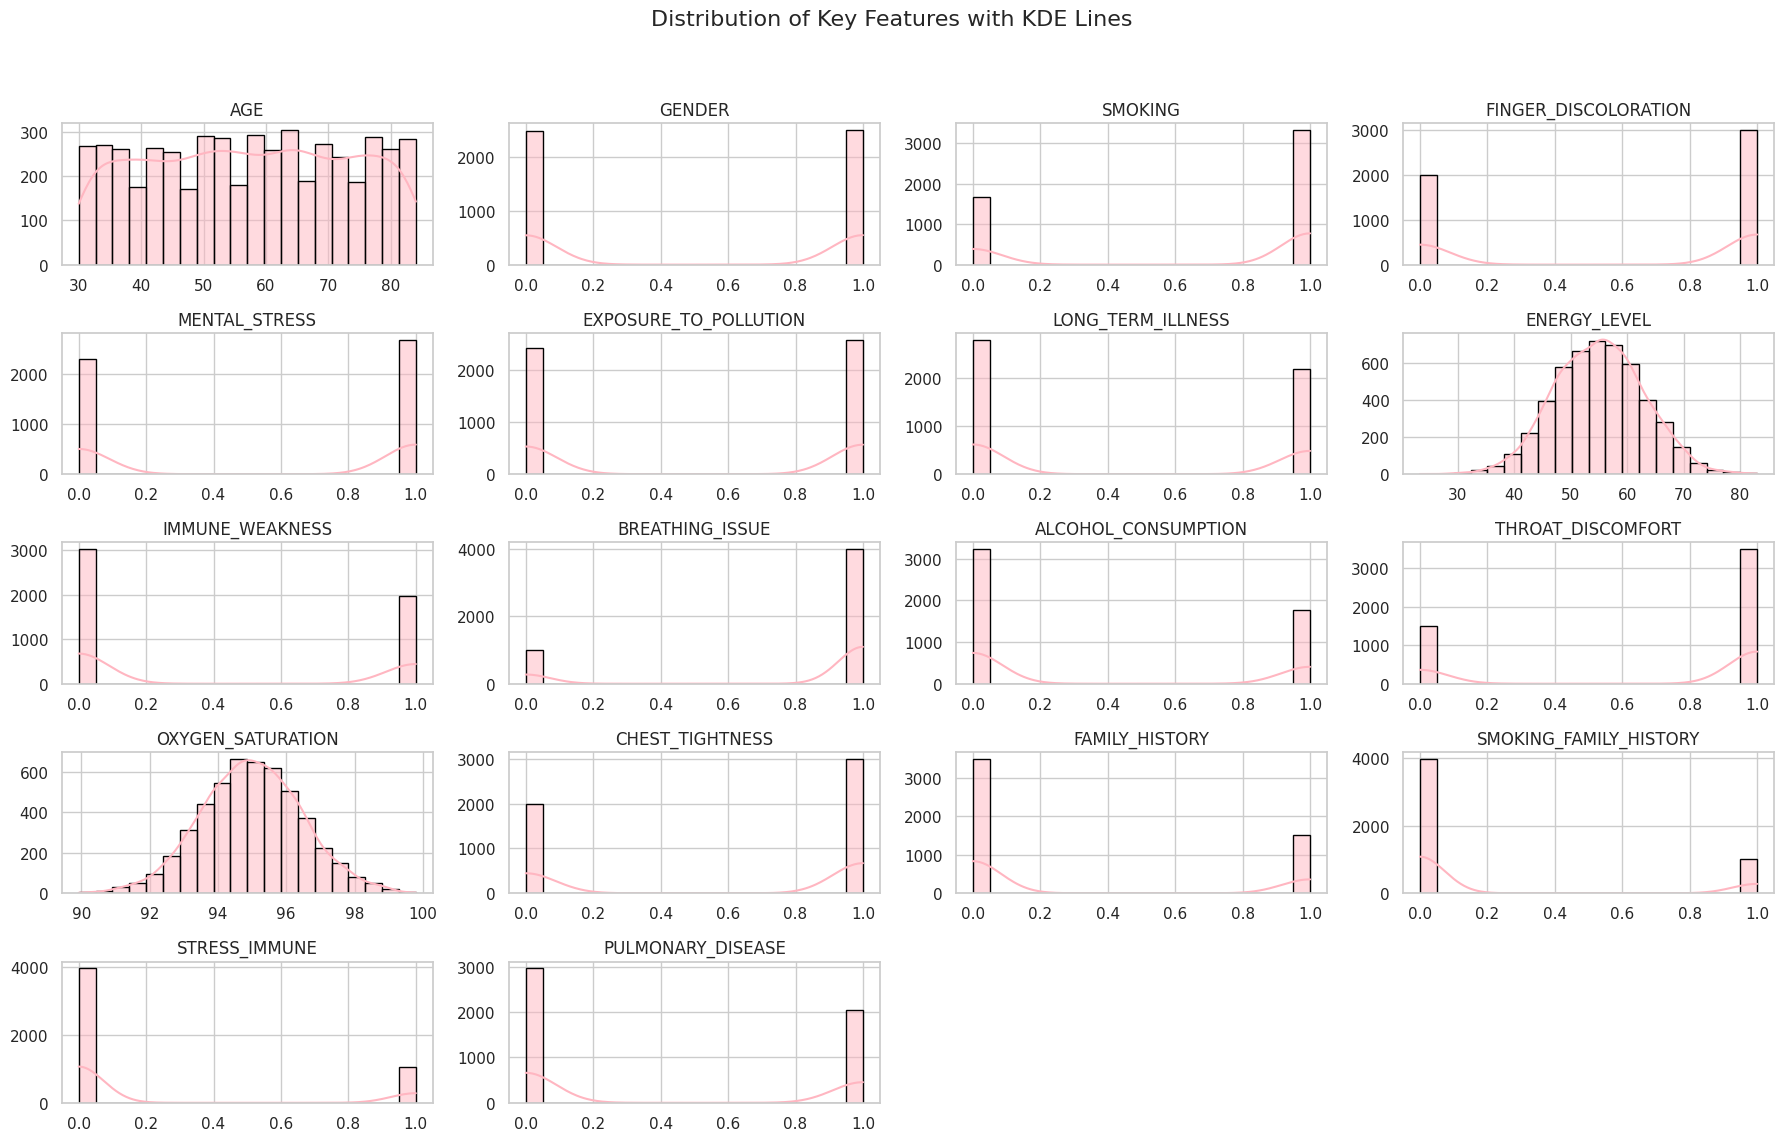

In [ ]:
# Set Seaborn style
sns.set(style="whitegrid")

# Create histograms with KDE line on top for each numerical feature
numeric_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns
num_plots = len(numeric_cols)
cols = 4
rows = (num_plots + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df_encoded[col], bins=20, kde=True, color="#FFB6C1", edgecolor="black", ax=axes[i])
    axes[i].set_title(f"{col}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Hide any empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribution of Key Features with KDE Lines", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# **Correlation Heatmap using Encoded Data**


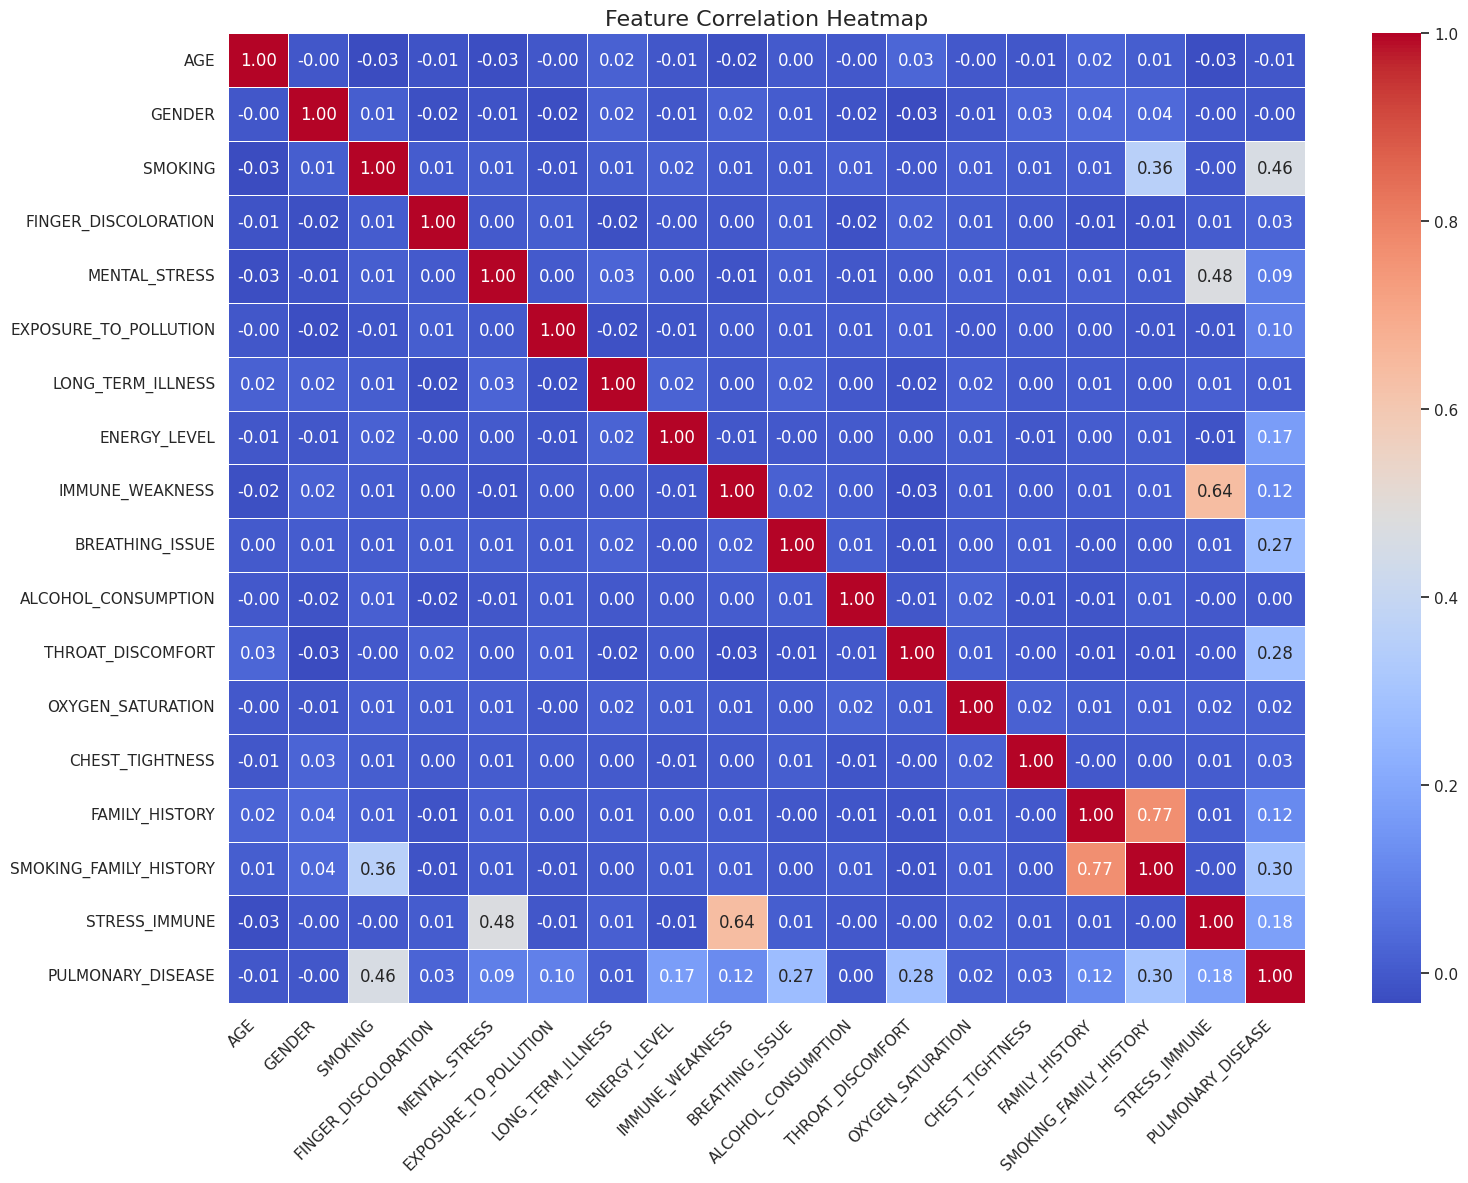

In [ ]:
# Correlation Heatmap (Using Encoded Data)
plt.figure(figsize=(16, 12))  # Increased size
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, square=False)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Feature Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

# **Boxplots for Oxygen Saturation vs Risk Factors**


In [ ]:
# Create a copy and ensure categorical columns are strings
df_categorical = df.copy()
for col in ['GENDER', 'SMOKING', 'ALCOHOL_CONSUMPTION', 'STRESS_IMMUNE', 'IMMUNE_WEAKNESS',
            'FAMILY_HISTORY', 'SMOKING_FAMILY_HISTORY', 'EXPOSURE_TO_POLLUTION']:
    df_categorical[col] = df_categorical[col].astype(str)


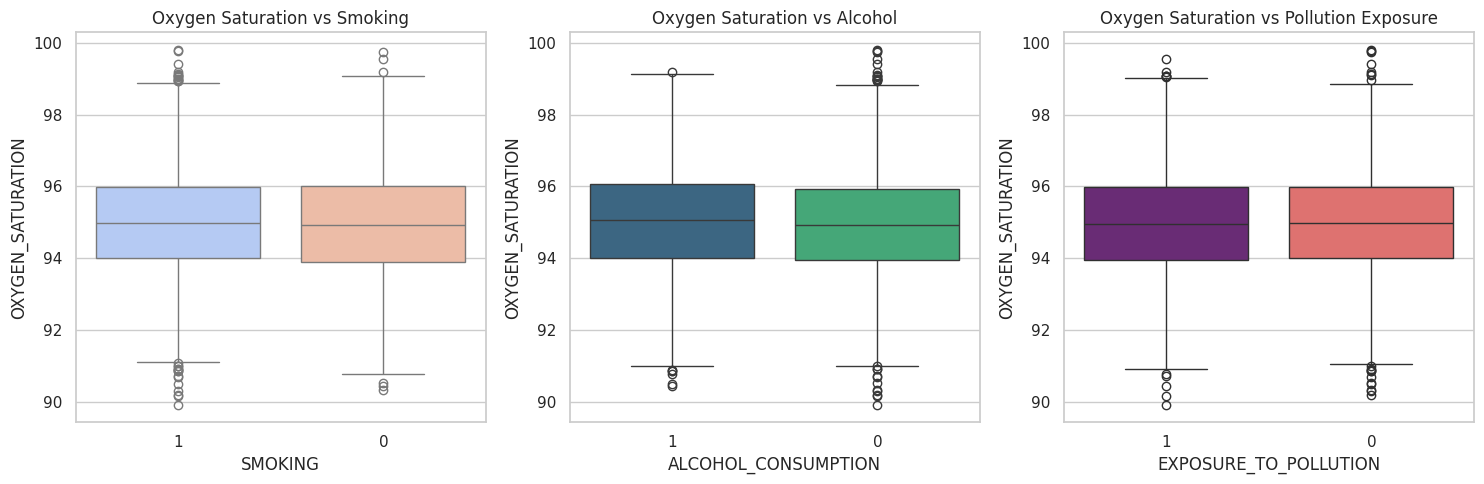

In [ ]:
# Boxplots for oxygen saturation vs risk factors
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(x="SMOKING", y="OXYGEN_SATURATION", data=df_categorical, ax=axes[0], palette="coolwarm")
axes[0].set_title("Oxygen Saturation vs Smoking")

sns.boxplot(x="ALCOHOL_CONSUMPTION", y="OXYGEN_SATURATION", data=df_categorical, ax=axes[1], palette="viridis")
axes[1].set_title("Oxygen Saturation vs Alcohol")

sns.boxplot(x="EXPOSURE_TO_POLLUTION", y="OXYGEN_SATURATION", data=df_categorical, ax=axes[2], palette="magma")
axes[2].set_title("Oxygen Saturation vs Pollution Exposure")

plt.tight_layout()
plt.show()

# **Pairplot**

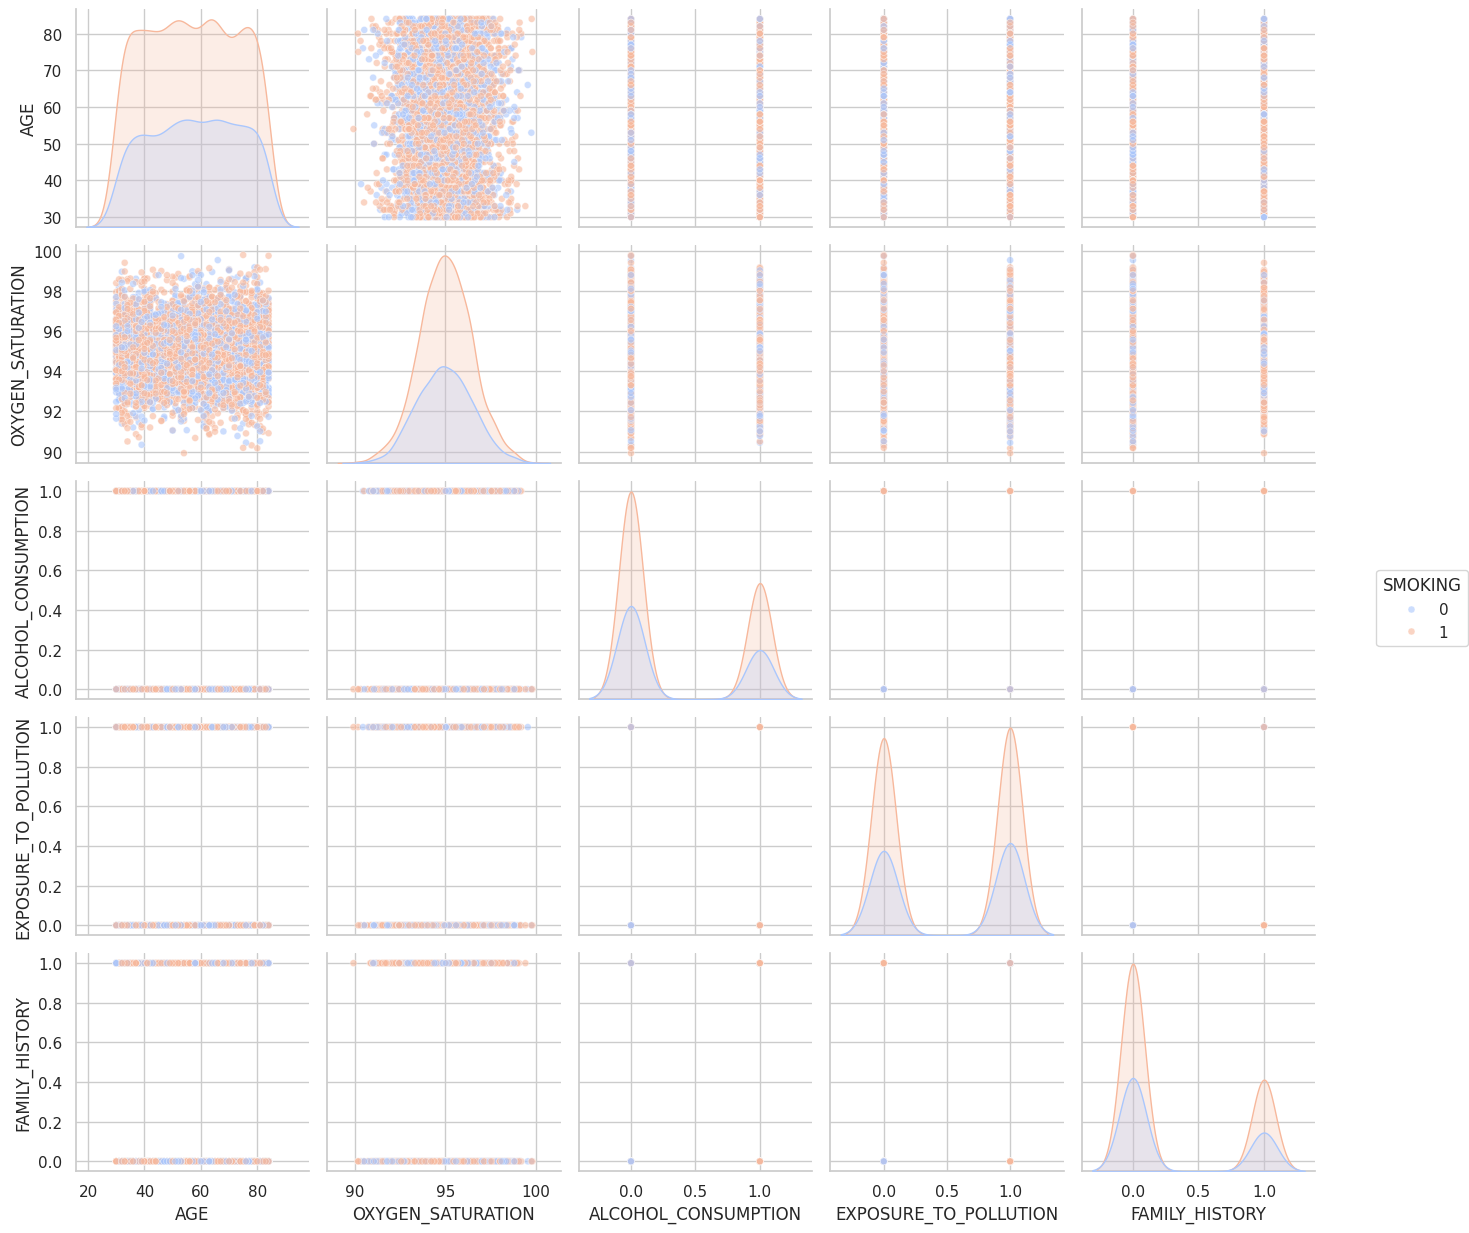

<Figure size 640x480 with 0 Axes>

In [ ]:
# Convert categorical variables to numerical using Label Encoding
df_encoded_pairplot = df.copy()
label_cols = ['SMOKING', 'ALCOHOL_CONSUMPTION', 'EXPOSURE_TO_POLLUTION', 'FAMILY_HISTORY']
for column in label_cols:
    df_encoded_pairplot[column] = LabelEncoder().fit_transform(df_encoded_pairplot[column])

# Select only numerical features
selected_features = ["AGE", "OXYGEN_SATURATION"] + label_cols
df_numeric = df_encoded_pairplot[selected_features]

# Improved Pairplot
# Create the pairplot
g = sns.pairplot(
    df_numeric,
    hue="SMOKING",
    palette="coolwarm",
    height=2.5,
    plot_kws={"s": 25, "alpha": 0.6},
    diag_kws={"fill": True}
)

# Move legend outside the grid
g._legend.set_title("SMOKING")
g._legend.set_bbox_to_anchor((1.1, 0.5))  # right side, center vertically
g._legend.set_frame_on(True)

plt.tight_layout()
plt.show()
plt.suptitle("Pairplot of Risk Factors by Smoking Status", fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

# **Data Split**

In [ ]:
# =================== Data Preprocessing ===================

# Encode target
le = LabelEncoder()
df['PULMONARY_DISEASE_encoded'] = le.fit_transform(df['PULMONARY_DISEASE'])

# Encode categorical features
features = df.drop(['PULMONARY_DISEASE', 'PULMONARY_DISEASE_encoded'], axis=1)
features = features.apply(lambda col: le.fit_transform(col) if col.dtype == 'object' else col)

# Define target
target = df['PULMONARY_DISEASE_encoded']

# Split data
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# =================== 1. KNN with GridSearch ===================

knn_param_grid = {
    'n_neighbors': list(range(1, 31)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

knn_grid = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=5, scoring='accuracy')
knn_grid.fit(X_train_scaled, y_train)
best_knn = knn_grid.best_estimator_
y_pred_knn = best_knn.predict(X_test_scaled)
knn_acc = accuracy_score(y_test, y_pred_knn)

In [ ]:
# =================== 2. Logistic Regression with GridSearch ===================

lr_param_grid = [
    {
        'penalty': ['l1', 'l2'],
        'C': np.logspace(-4, 4, 10),
        'solver': ['liblinear', 'saga']
    },
    {
        'penalty': ['elasticnet'],
        'C': np.logspace(-4, 4, 10),
        'solver': ['saga'],
        'l1_ratio': np.linspace(0, 1, 5)
    }
]

lr_grid = GridSearchCV(LogisticRegression(max_iter=1000), lr_param_grid, cv=5, scoring='accuracy')
lr_grid.fit(X_train_scaled, y_train)
best_lr = lr_grid.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, y_pred_lr)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import keras_tuner as kt
import pandas as pd
from sklearn.metrics import accuracy_score

# =================== 3. MLP with Keras Tuner + Early Stopping ===================

def build_mlp(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_scaled.shape[1],)))
    for i in range(hp.Int("num_layers", 1, 3)):
        model.add(layers.Dense(
            units=hp.Int(f"units_{i}", min_value=32, max_value=256, step=32),
            activation="relu",
            kernel_regularizer=regularizers.l1_l2(
                l1=hp.Float("l1", 1e-5, 1e-1, sampling="log"),
                l2=hp.Float("l2", 1e-5, 1e-1, sampling="log")
            )
        ))
    model.add(layers.Dense(1, activation="sigmoid"))
    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Float("lr", 1e-4, 1e-2, sampling="log")
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Define tuner
tuner = kt.RandomSearch(
    build_mlp,
    objective="val_accuracy",
    max_trials=20,
    executions_per_trial=1,
    directory="mlp_tuning",
    project_name="pulmonary_disease"
)

# Run tuner search
tuner.search(X_train_scaled, y_train, epochs=30, validation_split=0.2, verbose=0)

# Get best model and early stopping callback
best_mlp = tuner.get_best_models(1)[0]
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

# Train and capture history
history = best_mlp.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

# Epochs used before stopping
print(f"Training stopped at epoch: {len(history.history['accuracy'])}")

# Predictions and final test accuracy
y_pred_mlp = (best_mlp.predict(X_test_scaled) > 0.5).astype(int).flatten()
mlp_acc = accuracy_score(y_test, y_pred_mlp)
print(f"Final Test Accuracy: {mlp_acc:.4f}")

# Extract and display best elastic net parameters
best_hp = tuner.get_best_hyperparameters(1)[0]
best_l1 = best_hp.get('l1')
best_l2 = best_hp.get('l2')

elastic_net_params = pd.DataFrame({
    'Parameter': ['L1 Regularization', 'L2 Regularization'],
    'Best Value': [best_l1, best_l2]
})

print("\n🔍 Best Elastic Net Regularization Parameters Found by Keras Tuner:")
display(elastic_net_params)

Reloading Tuner from mlp_tuning/pulmonary_disease/tuner0.json
Training stopped at epoch: 7
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Final Test Accuracy: 0.9170

🔍 Best Elastic Net Regularization Parameters Found by Keras Tuner:


,Parameter,Best Value
0,L1 Regularization,0.002846
1,L2 Regularization,0.000013


# **Evaluation and Comparison**

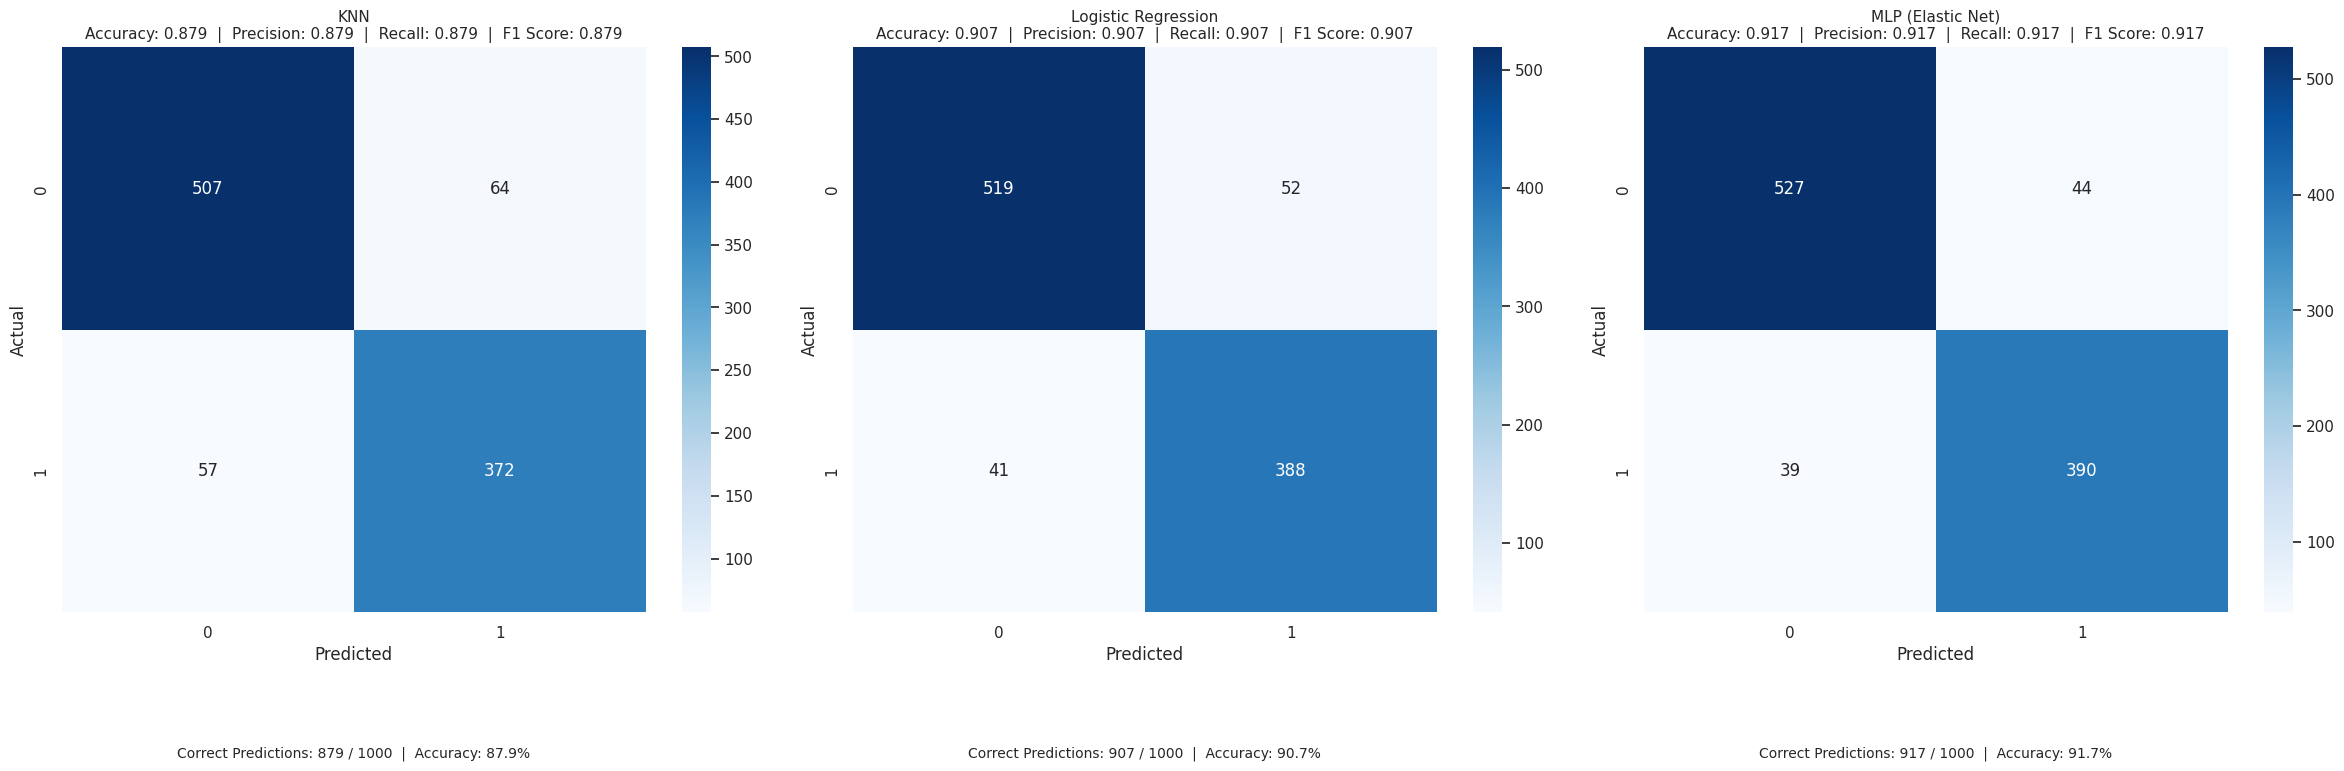


KNN Classification Report:
              precision    recall  f1-score   support

          NO       0.90      0.89      0.89       571
         YES       0.85      0.87      0.86       429

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000


Logistic Regression Classification Report:
              precision    recall  f1-score   support

          NO       0.93      0.91      0.92       571
         YES       0.88      0.90      0.89       429

    accuracy                           0.91      1000
   macro avg       0.90      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000


MLP (Elastic Net) Classification Report:
              precision    recall  f1-score   support

          NO       0.93      0.92      0.93       571
         YES       0.90      0.91      0.90       429

    accuracy                           0.92      1000
   macro avg  

In [ ]:
# Function to compute full metrics
def evaluate_model(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred, average='weighted'),
        "Recall (Weighted)": recall_score(y_true, y_pred, average='weighted'),
        "Precision (Weighted)": precision_score(y_true, y_pred, average='weighted'),
        "R2 Score": r2_score(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred)
    }

# Evaluate all models
metrics_df = pd.DataFrame({
    'KNN': evaluate_model(y_test, y_pred_knn),
    'Logistic Regression': evaluate_model(y_test, y_pred_lr),
    'MLP (Elastic Net)': evaluate_model(y_test, y_pred_mlp)
}).T.round(4)

from sklearn.metrics import classification_report

# Define names and predictions
model_names = ['KNN', 'Logistic Regression', 'MLP (Elastic Net)']
model_preds = [y_pred_knn, y_pred_lr, y_pred_mlp]

# Plot confusion matrices with detailed metrics in title
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for ax, name, preds in zip(axes, model_names, model_preds):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)

    # Classification report as dict
    report_dict = classification_report(y_test, preds, output_dict=True)

    # Extract weighted avg metrics
    weighted = report_dict['weighted avg']
    accuracy = report_dict['accuracy']  # same as acc from accuracy_score()

    # Build title text
    title = (
        f"{name}\n"
        f"Accuracy: {accuracy:.3f}  |  "
        f"Precision: {weighted['precision']:.3f}  |  "
        f"Recall: {weighted['recall']:.3f}  |  "
        f"F1 Score: {weighted['f1-score']:.3f}"
    )

    # Set plot title
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

    # Count correct predictions
    correct_preds = sum(y_test == preds)
    total = len(y_test)

    # Add correct prediction summary below
    ax.text(0.5, -0.25,
            f"Correct Predictions: {correct_preds} / {total}  |  Accuracy: {accuracy * 100:.1f}%",
            ha='center', va='center', transform=ax.transAxes, fontsize=10)

plt.tight_layout()
plt.show()

from sklearn.metrics import classification_report

# Print classification report for each model
for name, preds in zip(model_names, model_preds):
    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, preds, target_names=le.classes_ if hasattr(le, 'classes_') else None))


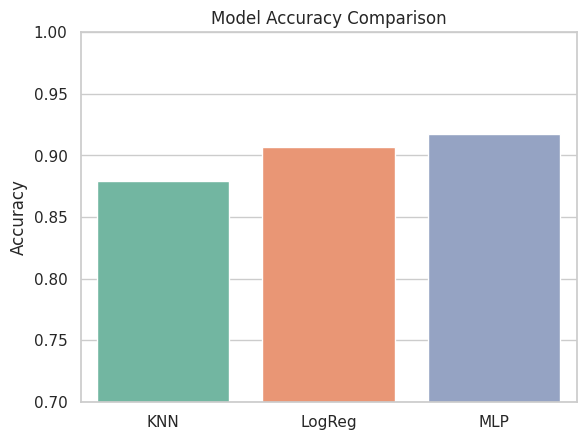

In [ ]:
sns.barplot(
    x=["KNN", "LogReg", "MLP"],
    y=[knn_acc, lr_acc, mlp_acc],
    palette="Set2"
)
plt.title("Model Accuracy Comparison")
plt.ylim(0.7, 1.0)
plt.ylabel("Accuracy")
plt.show()

# **Learning Rate**

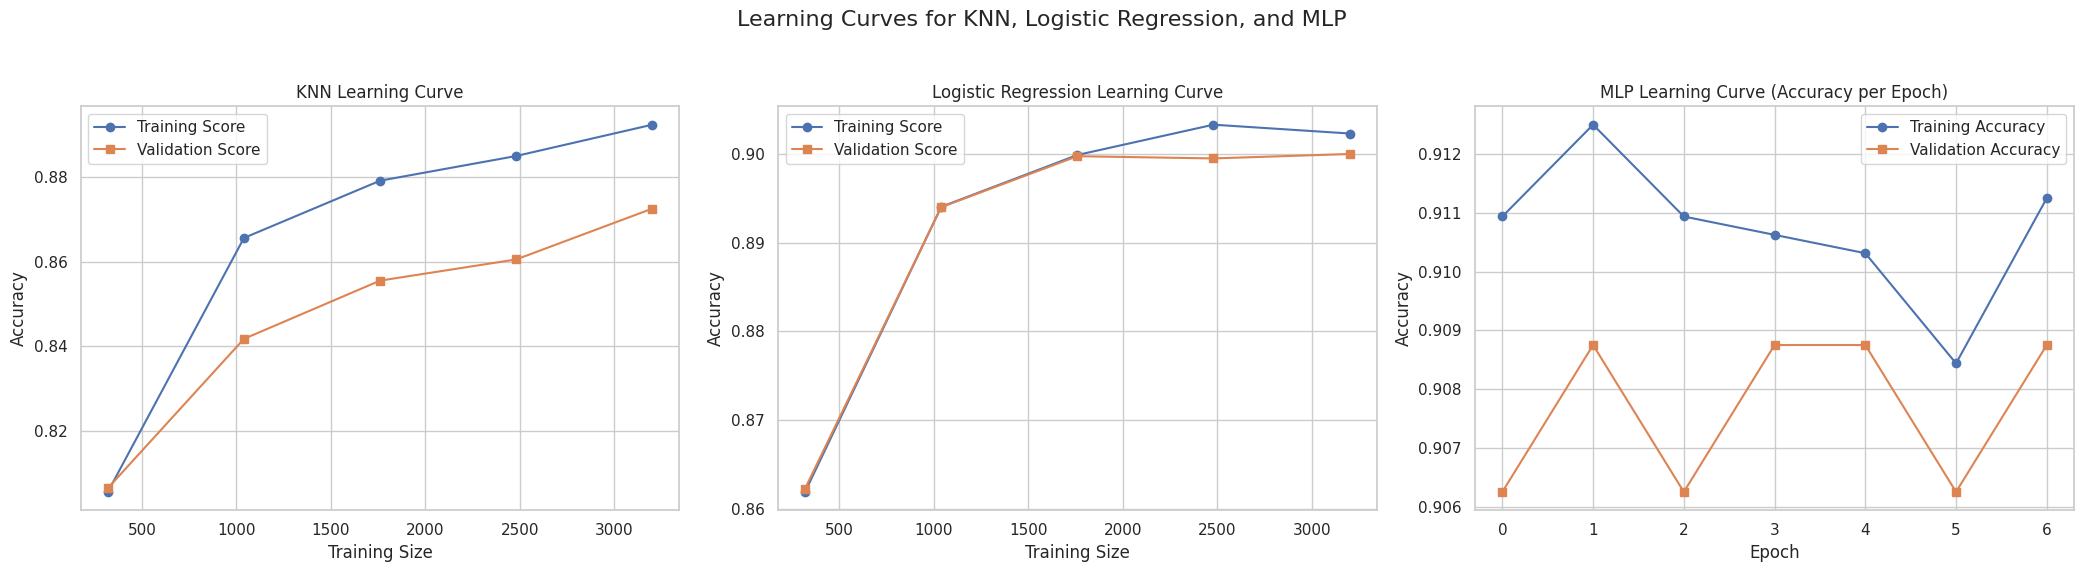

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
import numpy as np

# Reusable function for sklearn models
def plot_sklearn_learning_curve(estimator, title, X, y, ax):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=5, scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    ax.plot(train_sizes, train_mean, label="Training Score", marker='o')
    ax.plot(train_sizes, val_mean, label="Validation Score", marker='s')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Training Size")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(True)

# Start plotting
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# KNN and LR use sklearn's learning_curve
plot_sklearn_learning_curve(best_knn, "KNN Learning Curve", X_train_scaled, y_train, axes[0])
plot_sklearn_learning_curve(best_lr, "Logistic Regression Learning Curve", X_train_scaled, y_train, axes[1])

# MLP uses Keras history object
axes[2].plot(history.history['accuracy'], label='Training Accuracy', marker='o')
axes[2].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
axes[2].set_title("MLP Learning Curve (Accuracy per Epoch)", fontsize=12)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Accuracy")
axes[2].legend()
axes[2].grid(True)

plt.suptitle("Learning Curves for KNN, Logistic Regression, and MLP", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# **ROC Curve**

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


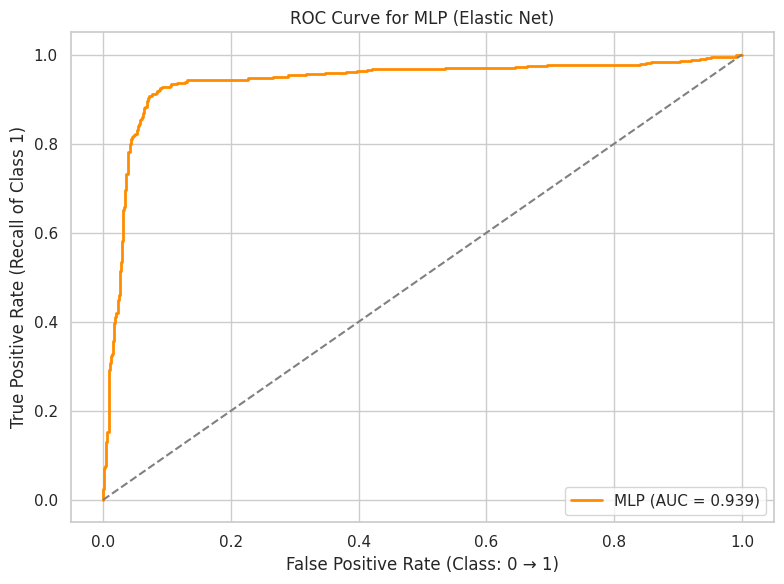

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probabilities from MLP
y_prob_mlp = best_mlp.predict(X_test_scaled).flatten()

# ROC calculation
fpr, tpr, _ = roc_curve(y_test, y_prob_mlp)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"MLP (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlabel("False Positive Rate (Class: 0 → 1)")
plt.ylabel("True Positive Rate (Recall of Class 1)")
plt.title("ROC Curve for MLP (Elastic Net)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()